In [2]:
# for interactive plots:
# %matplotlib widget

# for static plots:
%matplotlib inline

In [3]:
import matplotlib.pyplot as plt

# Optics calculation and matching

For more info, see [Twiss](https://xsuite.readthedocs.io/en/latest/twiss.html) and [Match](https://xsuite.readthedocs.io/en/latest/match.html) sections in the User's Guide.

In [4]:
import xtrack as xt

### Load model

In [19]:
env = xt.load('./pimm.json')
ring = env.ring
ring.set_particle_ref('proton', p0c=200e6)

Loading line from dict:   0%|          | 0/86 [00:00<?, ?it/s]

### Set some initial strengths to get a first twiss

In [20]:
env['kqfa'] =  0.01
env['kqfb'] =  0.01
env['kqd']  = -0.02

In [21]:
# Compute twiss parameters
tw = ring.twiss4d(chrom=False)

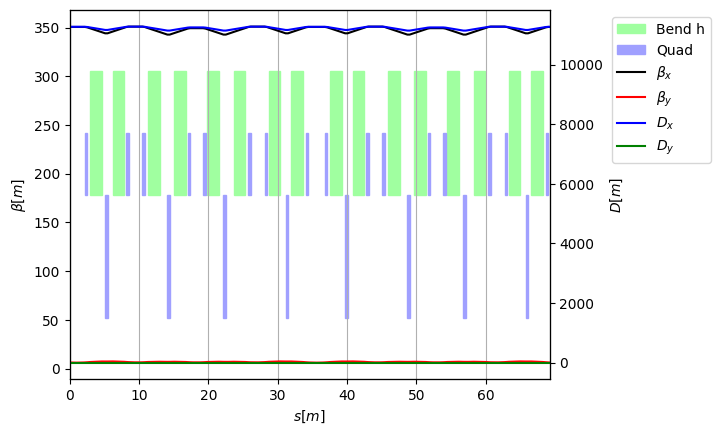

In [22]:
# Plot twiss parameters
tw.plot()

### Match the tunes

In [23]:
opt_tune = ring.match(
    solve=False, # <- prepare the match without running it
    chrom=False,
    method='4d',
    vary=[
        xt.Vary('kqfa', limits=(0, 10),  step=1e-3),
        xt.Vary('kqfb', limits=(0, 10),  step=1e-3),
        xt.Vary('kqd', limits=(-10, 0), step=1e-3),
    ],
    targets=[
        xt.TargetSet(qx=1.64, qy=1.72, tol=1e-6),
    ]
)

In [24]:
opt_tune.target_status()

Target status:               alty = 1.6107e+01              
id state tag tol_met       residue   current_val    target_val description                         
0  ON    qx    False      -1.60864     0.0313631          1.64 'qx', val=1.64, tol=1e-06, weight=10
1  ON    qy    False    -0.0807693       1.63923          1.72 'qy', val=1.72, tol=1e-06, weight=10


In [25]:
opt_tune.run_jacobian(30)

                                             
Optimize - start penalty: 16.11                             
Matching: model call n. 32 penalty = 1.3669e-08              
Optimize - end penalty:  1.36687e-08                            


In [26]:
opt_tune.target_status()

Target status:               nalty = 1.3669e-08              
id state tag tol_met       residue   current_val    target_val description                         
0  ON    qx     True  -1.36671e-09          1.64          1.64 'qx', val=1.64, tol=1e-06, weight=10
1  ON    qy     True   -2.1114e-11          1.72          1.72 'qy', val=1.72, tol=1e-06, weight=10


In [27]:
opt_tune.vary_status()

Vary status:                 
id state tag met name lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON        OK  kqfa           0      0.435867          10          0.01         0.001             1
1  ON        OK  kqfb           0      0.440097          10          0.01         0.001             1
2  ON        OK  kqd          -10     -0.585124           0         -0.02         0.001             1


### Inspect the optics

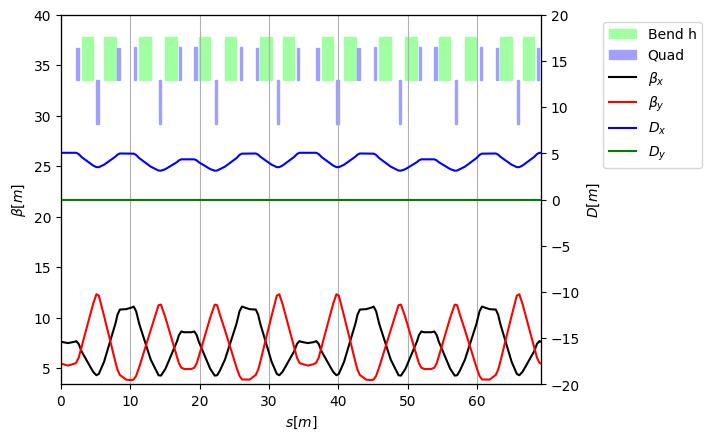

In [28]:
# Twiss and plot again
tw = ring.twiss4d()
pl = tw.plot()
pl.ylim(left_hi=40, right_lo=-20, right_hi=20,
        lattice_hi=1.5, lattice_lo=-7)

### Add constraint on dispersion at the center of the long straight sections

In [29]:
opt_disp = opt_tune.clone(
    add_targets=[
        xt.TargetSet(dx=0, at='mid.lss.0', tol=1e-3),
        xt.TargetSet(dx=0, at='mid.lss.1', tol=1e-3),
    ])

In [30]:
opt_disp.target_status()

Target status:               alty = 7.1697e+01              
id state tag          tol_met       residue   current_val    target_val description                                 
0  ON    qx              True  -1.36671e-09          1.64          1.64 'qx', val=1.64, tol=1e-06, weight=10        
1  ON    qy              True   -2.1114e-11          1.72          1.72 'qy', val=1.72, tol=1e-06, weight=10        
2  ON    mid.lss.0_dx   False       5.06976       5.06976             0 ('dx', 'mid.lss.0'), val=0, tol=0.001, w ...
3  ON    mid.lss.1_dx   False       5.06976       5.06976             0 ('dx', 'mid.lss.1'), val=0, tol=0.001, w ...


In [31]:
opt_disp.run_simplex(100)

                                             
Optimize - start penalty: 71.7                              
Matching: model call n. 185 penalty = 6.5468e-05              
Optimize - end penalty:  6.54676e-05                            


### Inspect the optics

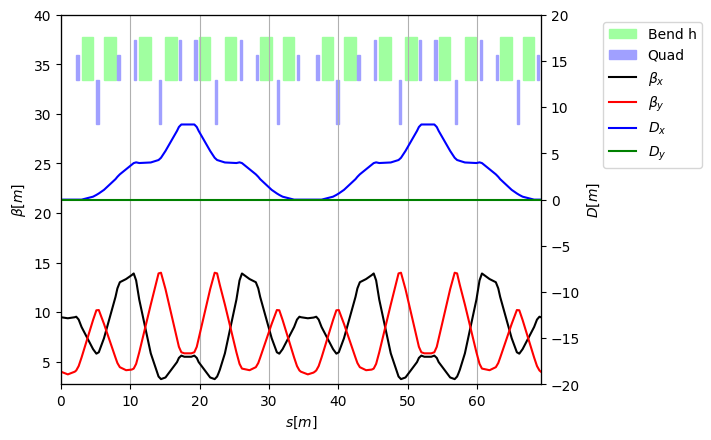

In [32]:
tw = ring.twiss4d()
pl = tw.plot()
pl.ylim(left_hi=40, right_lo=-20, right_hi=20,
        lattice_hi=1.5, lattice_lo=-7)

In [35]:
env.ref['ksf'].xdeps.info()

Info for vars['ksf']

value: 0.0

Not controlled by other entities.

controlled_targets:
   element_refs['msf.2'].k2
   element_refs['msf.1'].k2



In [37]:
# Zero chromaticity
opt_chrom = ring.match(
    method='4d',
    vary=[
        xt.VaryList(['ksf', 'ksd'], step=1e-3),
    ],
    targets=[
        xt.TargetSet(dqx=0, dqy=0, tol=1e-5),
    ]
)

                                             
Optimize - start penalty: 1.215                             
Matching: model call n. 11 penalty = 2.3995e-07              
Optimize - end penalty:  2.39955e-07                            


In [40]:
# Match horizontal Q' knob
opt = ring.match_knob(
    run=False, # <- prepare the match without running it
    knob_name='chrom_x',
    knob_value_start=0,
    knob_value_end=1,
    method='4d',
    vary=[
        xt.VaryList(['ksf', 'ksd'], step=1e-3),
    ],
    targets=[
        xt.TargetSet(dqx=1., dqy=0, tol=1e-4),
    ]
)
opt.step(20)
opt.target_status()
opt.generate_knob()

                                             
Optimize - start penalty: 1                                 
Matching: model call n. 6 penalty = 4.9870e-05              
Optimize - end penalty:  4.987e-05                            
Target status:               alty = 4.9870e-05              
id state tag tol_met       residue   current_val    target_val description                       
0  ON    dqx    True   4.98699e-05       1.00005             1 'dqx', val=1, tol=0.0001, weight=1
1  ON    dqy    True  -9.58611e-08  -9.58611e-08             0 'dqy', val=0, tol=0.0001, weight=1
Generated knob:  chrom_x                       


In [41]:
# Match vertical Q' knob
opt = ring.match_knob(
    run=False, # <- prepare the match without running it
    knob_name='chrom_y',
    knob_value_start=0,
    knob_value_end=1,
    method='4d',
    vary=[
        xt.VaryList(['ksf', 'ksd'], step=1e-3),
    ],
    targets=[
        xt.TargetSet(dqx=0, dqy=1., tol=1e-4),
    ]
)
opt.step(20)
opt.target_status()
opt.generate_knob()

                                             
Optimize - start penalty: 1                                 
Matching: model call n. 11 penalty = 2.3478e-07              
Optimize - end penalty:  2.34781e-07                            
Target status:               nalty = 2.3478e-07              
id state tag tol_met       residue   current_val    target_val description                       
0  ON    dqx    True   2.34781e-07   2.34781e-07             0 'dqx', val=0, tol=0.0001, weight=1
1  ON    dqy    True   2.22045e-12             1             1 'dqy', val=1, tol=0.0001, weight=1
Generated knob:  chrom_y                       


In [43]:
tt_vars = env.vars.get_table()

In [47]:
tt_strengths = tt_vars.rows['k.*']

In [50]:
tt_strengths.to_json('pimm_strengths.json')